# Chapter 5 - Dictionaries and Functions as Arguments

Housekeeping item:

Today we'll be using the `ChemicalSymbols.csv` and `ChemicalSymbolsZ.csv` files in the miscellaneous files module on canvas. Download it and put it alongside our lecture notes for today. 

## Dictionaries

Dictionaries are another data type in Python that is useful for complex data representation (like arrays). Dictionaries are special lists where the elements are accessed via special names, called keys.

More technically, a dictionary is a set of key:value pairs.  The key is the analog to the index of a list, and is, in effect the name of the item.  Dictionaries are defined using curly braces: { }

In [30]:
#simple dictionary
days_of_week = {"M":"Monday", "T":"Tuesday",
                "W":"Wednesday", "R":"Thursday",
                "F":"Friday", "S":"Saturday",
                "U":"Sunday"}
print("Key M gives", days_of_week["M"])
print("Key R gives", days_of_week["R"])


Key M gives Monday
Key R gives Thursday


This example uses the *in* operator to indicate if a particular key is in a dictionary. In particular, it tells us that "G"is not a key in the dictionary.

In [31]:
#is G a key in days_of_week?
print("G" in days_of_week.keys())
print("Monday" in days_of_week.values())

False
True


What happens when we try to access an item that isn't in the dictionary? 

In [32]:
days_of_week["G"]

KeyError: 'G'

Here's a cool example of creating a dictionary that relates the chemical symbol for an element to its name.  Also, we use the csv library to import a file in the comma-separated-value (csv) format. First let's take a look at the file: 

In [ ]:
!cat ChemicalSymbols.csv | head -n 5

'cat' is not recognized as an internal or external command,
operable program or batch file.


Now let's load the file into a dictionary object. 

In [1]:
import csv
#create an empty dictionary
element_dict = {}

#this block will only execute if the file opens
#filepath = r"C:\Users\AgniP\AppData\Roaming\Code\User\globalStorage\github.remotehub\57d3fc8bea6d7517af96031f0da7c50d\changestore\vscode-vfs-github\Nathan-Carpenter\NSE-223\Coding-Notes\ChemicalSymbols.csv"
filepath = "ChemicalSymbols.csv"
with open(filepath) as csvfile:
    chemreader = csv.reader(csvfile)
    #have for loop that loops over each line
    for row in chemreader:
        #add a key:value pair
        element_dict[row[0]]=row[1]

FileNotFoundError: [Errno 2] No such file or directory: 'ChemicalSymbols.csv'

We ask the user to input a chemical symbol, and return the name.

In [41]:
key = str(input("Enter a valid chemical symbol: "))
if key in element_dict:
    print(key,"is",element_dict[key])
else:
    print("Not a valid element")

K is Potassium


Note: 
* Shift+Enter with the input option will make the cell keep trying to execute. Use a simple Enter after inputting the element you want. 
* line endings have different representations in UNIX and DOS systems.


That was a rather fancy way of accessing the element in the dictionary. Under the hood, we accessed the `value` of the element by using the `key`. Because this is a dictionary, it may be helpful to think of the `key` as a word, and `value` as the definition or variable associated with the word. 

In [ ]:
element_dict["K"]

'Potassium'

As crazy as it sounds, you can also have dictionaries of dictionaries: the value in the key:value pair can be another dictionary!  Crazy...

In [ ]:
#simple dictionary of dictionaries
days_of_week = {"M":{"name":"Monday","weekday":True,"weekend":False},
                "T":{"name":"Tuesday","weekday":True,"weekend":False},
                "W":{"name":"Wednesday","weekday":True,"weekend":False},
                "R":{"name":"Thursday","weekday":True,"weekend":False},
                "F":{"name":"Friday","weekday":True,"weekend":False},
                "S":{"name":"Saturday","weekday":False,"weekend":True},
                "U":{"name":"Sunday","weekday":False,"weekend":True}}

print("The days that are weekdays:")
for day in days_of_week: #for loop over dictionary, loops over keys
    if days_of_week[day]["weekday"] == True:
        print(days_of_week[day]["name"],"is a weekday. More coffee please.")
for day in days_of_week: #for loop over dictionary, loops over keys
    if days_of_week[day]["weekend"] == True:
        print(days_of_week[day]["name"],"is a weekend, woohoo!!!!!!!!!!") 




The days that are weekdays:
Monday is a weekday. More coffee please.
Tuesday is a weekday. More coffee please.
Wednesday is a weekday. More coffee please.
Thursday is a weekday. More coffee please.
Friday is a weekday. More coffee please.
Saturday is a weekend, woohoo!!!!!!!!!!
Sunday is a weekend, woohoo!!!!!!!!!!


Let's go back and try some more loading. Now we'll access a different file that sorts elements by their atomic number.
Peeking at the file.... 

In [ ]:
!cat ChemicalSymbolsZ.csv | head -n 5

89,Ac,Actinium
47,Ag,Silver
13,Al,Aluminium (Aluminum)
95,Am,Americium
18,Ar,Argon


We will create a dictionary where the key is the atomic number (Z), and the value will be a dictionary with the element name and symbol.

In [ ]:
import csv
element_dict = {} #create a blank dictionary
#this block will only execute if the file opens
with open("ChemicalSymbolsZ.csv") as csvfile:
    chemreader = csv.reader(csvfile)
    #have for loop that loops over each row
    for row in chemreader:
        #add a key:value pair
        element_dict[row[0]]={"symbol":row[1], "name":row[2]}

In [ ]:
key = input("Enter a valid atomic number: ")
if key in element_dict:
    print(key,"is",element_dict[key]["symbol"],
          ":",element_dict[key]["name"])
else:
    print("Not a valid element")

13 is Al : Aluminium (Aluminum)


This is the same thing as doing: 

In [ ]:
element_dict['16']

{'symbol': 'S', 'name': 'Sulfur (Sulphur)'}

In [ ]:
simple_dict = {1:4,5:8}

In [ ]:
simple_dict[5]

8

*Dictionary Example*: We can use the dictionary of dictionaries to develop a function that will compute the product of an alpha decay:

Given that we have a dictionary where we can look up an element by its atomic number, we can write a function that computes the product of alpha decay of a particular nuclide. 
- We will pass the function the atomic number, the mass number, and the dictionary of elements. 
- It will return the atomic number and the mass number of the product, along with printing some information to the screen.

In [ ]:
def alpha_decay(Z,A,elements):
    """Alpha decay a nuclide
    Args:
        Z: atomic number of nuclide
        A: mass number of nuclide
        elements: dictionary of elements
        Returns:
            Z and A of daughter nuclide (both ints)
    Side effects:
        Prints a descriptive string of the decay
        """
    newZ = int(Z) - 2 #lose two protons in alpha decay
    newA = int(A) - 4 #lose four nucleons in alpha decay
    print(elements[str(Z)]["name"],"-",A,"(",
          elements[str(Z)]["symbol"],"-",A,"), alpha decays to",
          elements[str(newZ)]["name"],"-",newA,"(",
          elements[str(newZ)]["symbol"],"-",newA,")")
    return newZ,newA

z_value = input("Enter the Z of the nuclide: ")
a_value = input("Enter the mass number of the nuclide: ")
Z,A = alpha_decay(z_value, a_value, element_dict)

Aluminium (Aluminum) - 13 ( Al - 13 ), alpha decays to Sodium - 9 ( Na - 9 )


Given that the function returns the atomic and mass numbers of the products, we can run alpha_decayin a loop.

In [ ]:
#alpha decay something 10 times
Z = 94
A = 239
for decays in range(10):
    Z,A = alpha_decay(Z, A, element_dict)

Plutonium - 239 ( Pu - 239 ), alpha decays to Uranium - 235 ( U - 235 )
Uranium - 235 ( U - 235 ), alpha decays to Thorium - 231 ( Th - 231 )
Thorium - 231 ( Th - 231 ), alpha decays to Radium - 227 ( Ra - 227 )
Radium - 227 ( Ra - 227 ), alpha decays to Radon - 223 ( Rn - 223 )
Radon - 223 ( Rn - 223 ), alpha decays to Polonium - 219 ( Po - 219 )
Polonium - 219 ( Po - 219 ), alpha decays to Lead - 215 ( Pb - 215 )
Lead - 215 ( Pb - 215 ), alpha decays to Mercury - 211 ( Hg - 211 )
Mercury - 211 ( Hg - 211 ), alpha decays to Platinum - 207 ( Pt - 207 )
Platinum - 207 ( Pt - 207 ), alpha decays to Osmium - 203 ( Os - 203 )
Osmium - 203 ( Os - 203 ), alpha decays to Tungsten - 199 ( W - 199 )


*Another example*: keeping data about different nuclear fuel types. 

- We will consider a reactor that has two types of fuel, high-enriched uranium (HEU) and low-enriched uranium (LEU). 
- We will use a dictionary to describe the properties of each type of fuel. 
- Then using this information, we plot the HEU fuel geometric cross-section.

In [ ]:
fuel_types = {}
fuel_types["heu"] = {"fuel":{"nu sigma_f":12.0,
                             "D":3.0, "thickness":5.0},
                     "clad":{"nu sigma_f":0.0, 
                             "D":300.0, "thickness":0.5}}
fuel_types["leu"] = {"fuel":{"nu sigma_f":8.5,
                             "D":1.25, "thickness":4.25},
                     "clad":{"nu sigma_f":0.0,
                             "D":300.0, "thickness":1.25}}

How is data about fuel rods stored?

Define a dictionary called 'fuel_types'

- key: fuel type ("heu", "leu")
- content: another dictionary
    - key: fuel component name ("fuel", "cladding")
    - content: another dictionary
        - key: "nu_sigma_f", "D", "thickness"

nu_sigma_f: the macroscopic fission cross section multiplied by ν (nu), the average number of neutrons produced per fission.
D: diffusion coefficient
thickness: radius for fuel meat and thickness for cladding

Let's plot a HEU rod. What do we need?
- fuel radius
- cladding radius

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


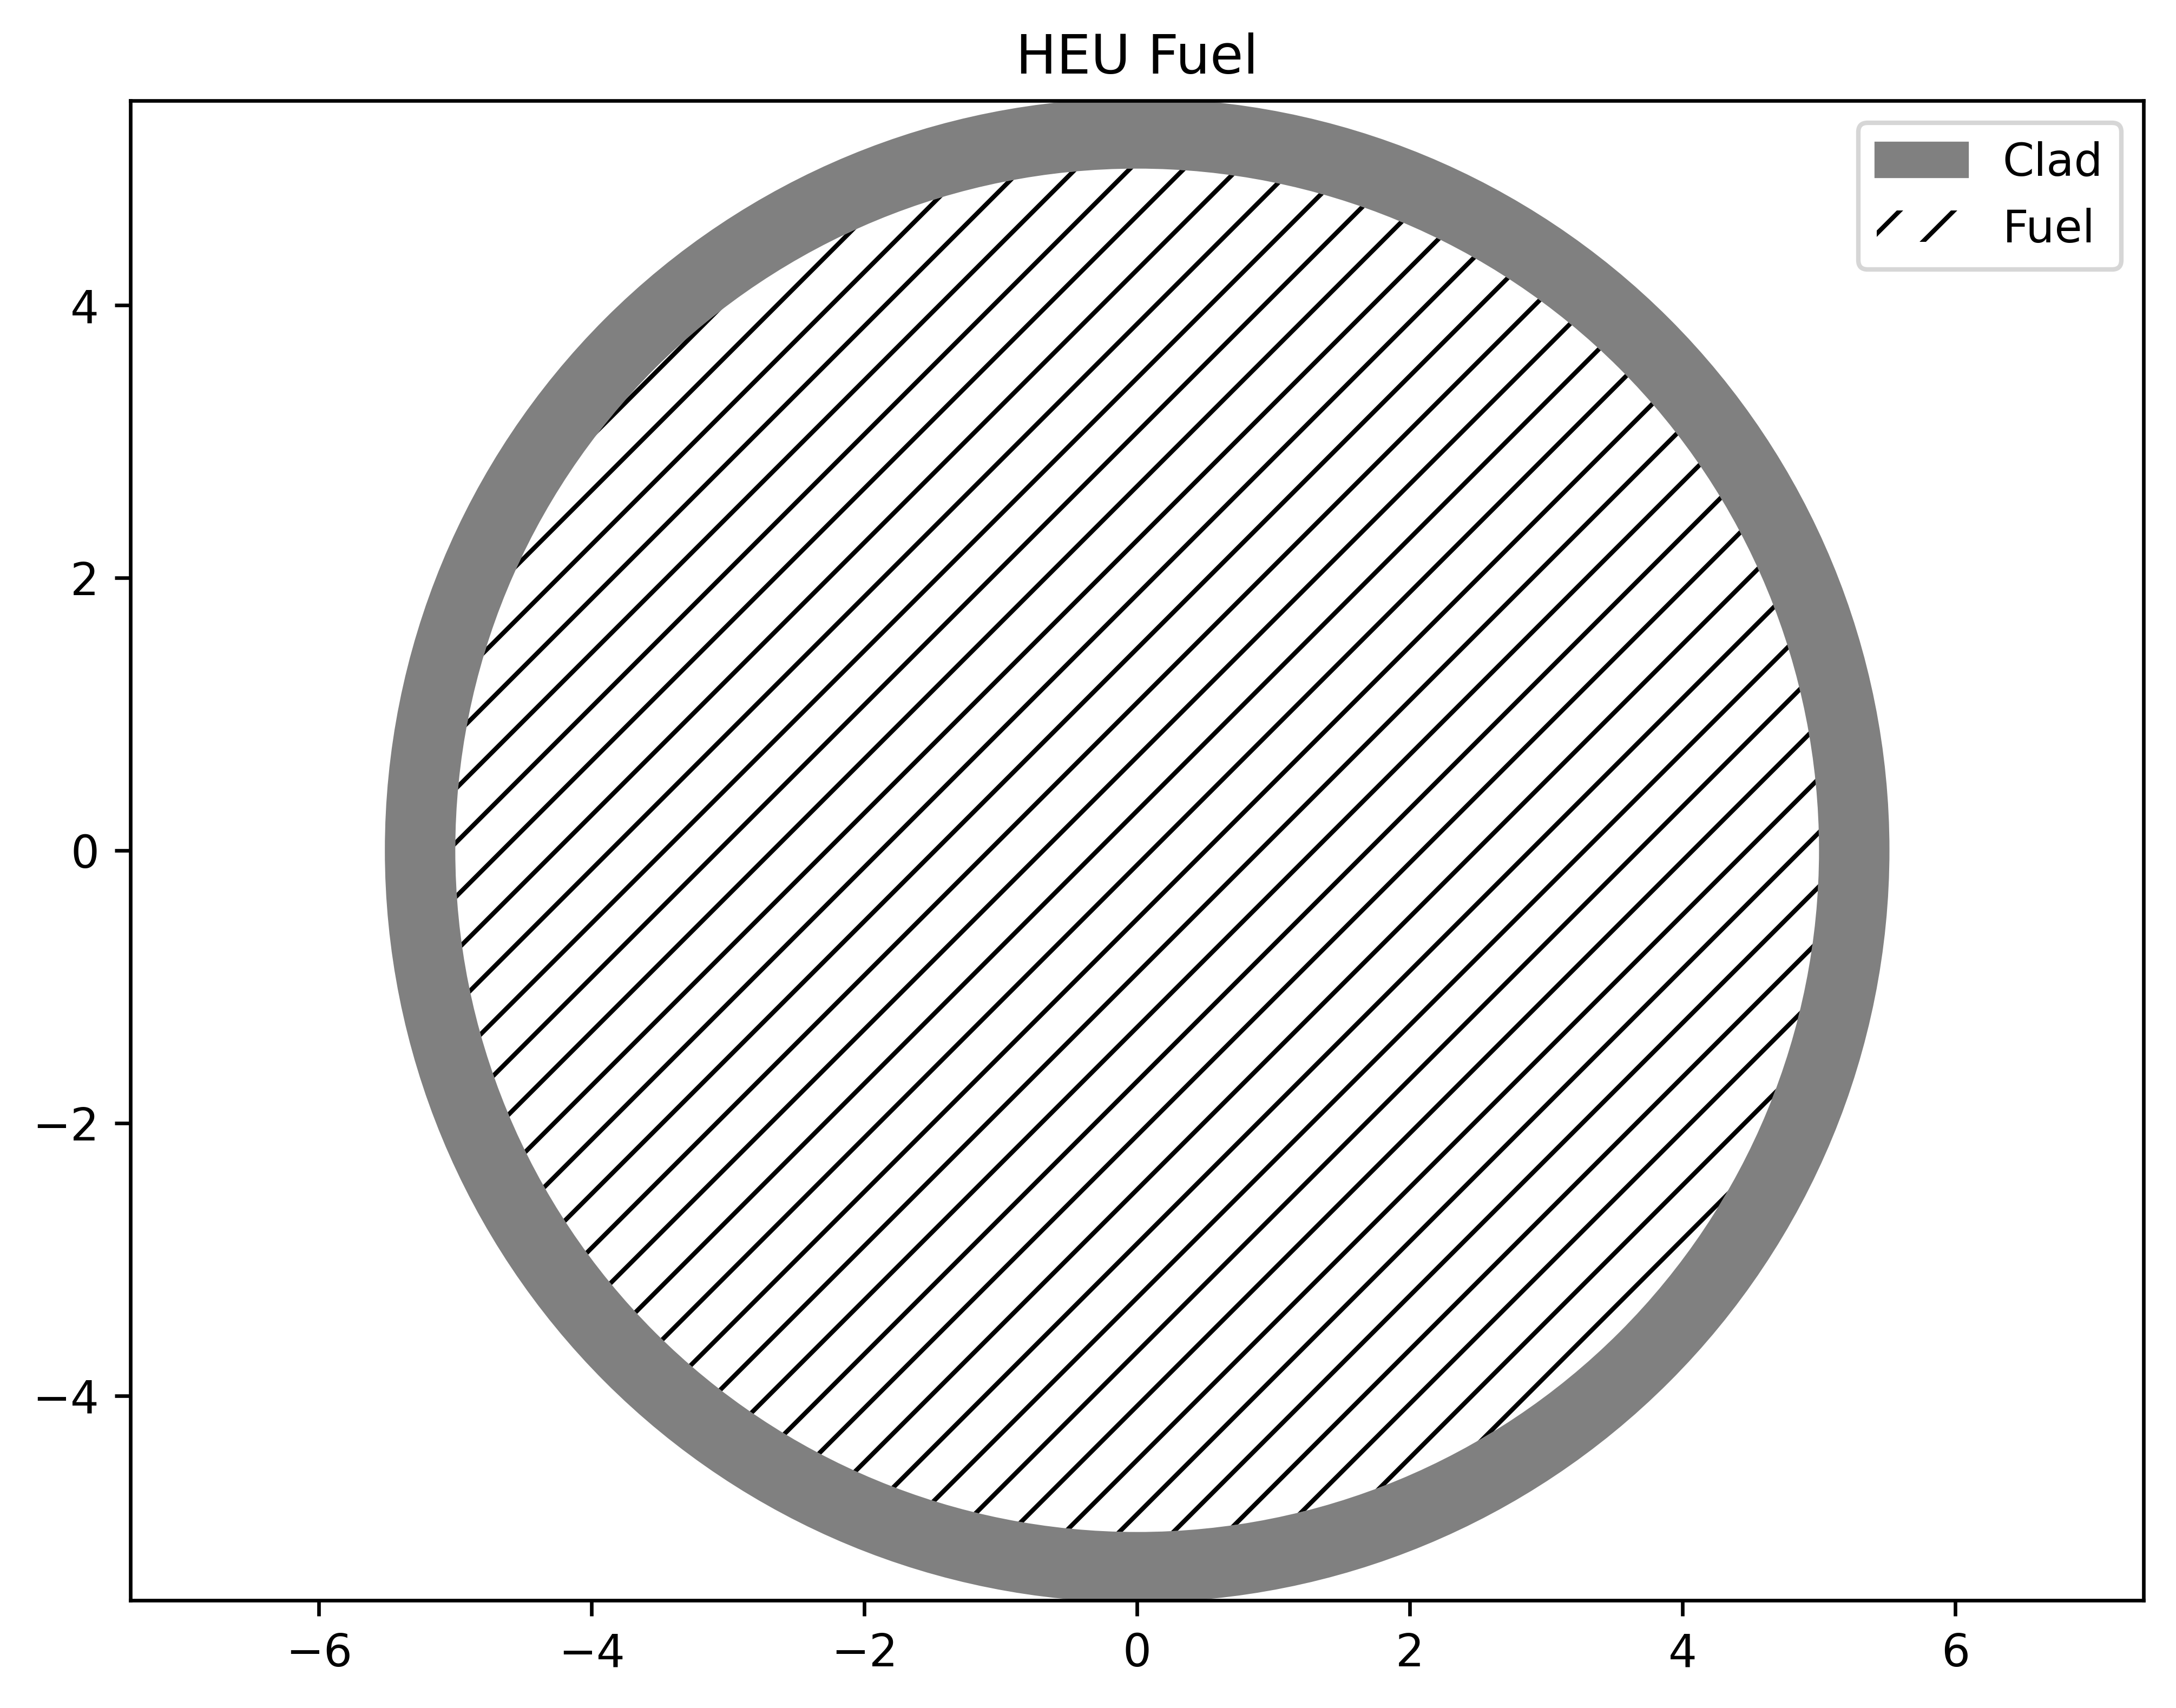

In [ ]:
#plot heu
#heu fuel
import matplotlib.pyplot as plt

fuel_radius = fuel_types["heu"]["fuel"]["thickness"]
clad_radius = fuel_radius + fuel_types["heu"]["clad"]["thickness"]


fuel = plt.Circle((0,0),fuel_radius,
                  facecolor="white",label="Fuel", hatch="//")
clad = plt.Circle((0,0),clad_radius,color="gray",label="Clad")
fig = plt.figure(figsize=(8,6), dpi=600)
plt.gca().add_patch(clad)
plt.gca().add_patch(fuel)
plt.title("HEU Fuel")
plt.axis("equal")
plt.legend()
plt.axis([-clad_radius,clad_radius,-clad_radius,clad_radius])
plt.show();

We can do the same thing for the LEU fuel:

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


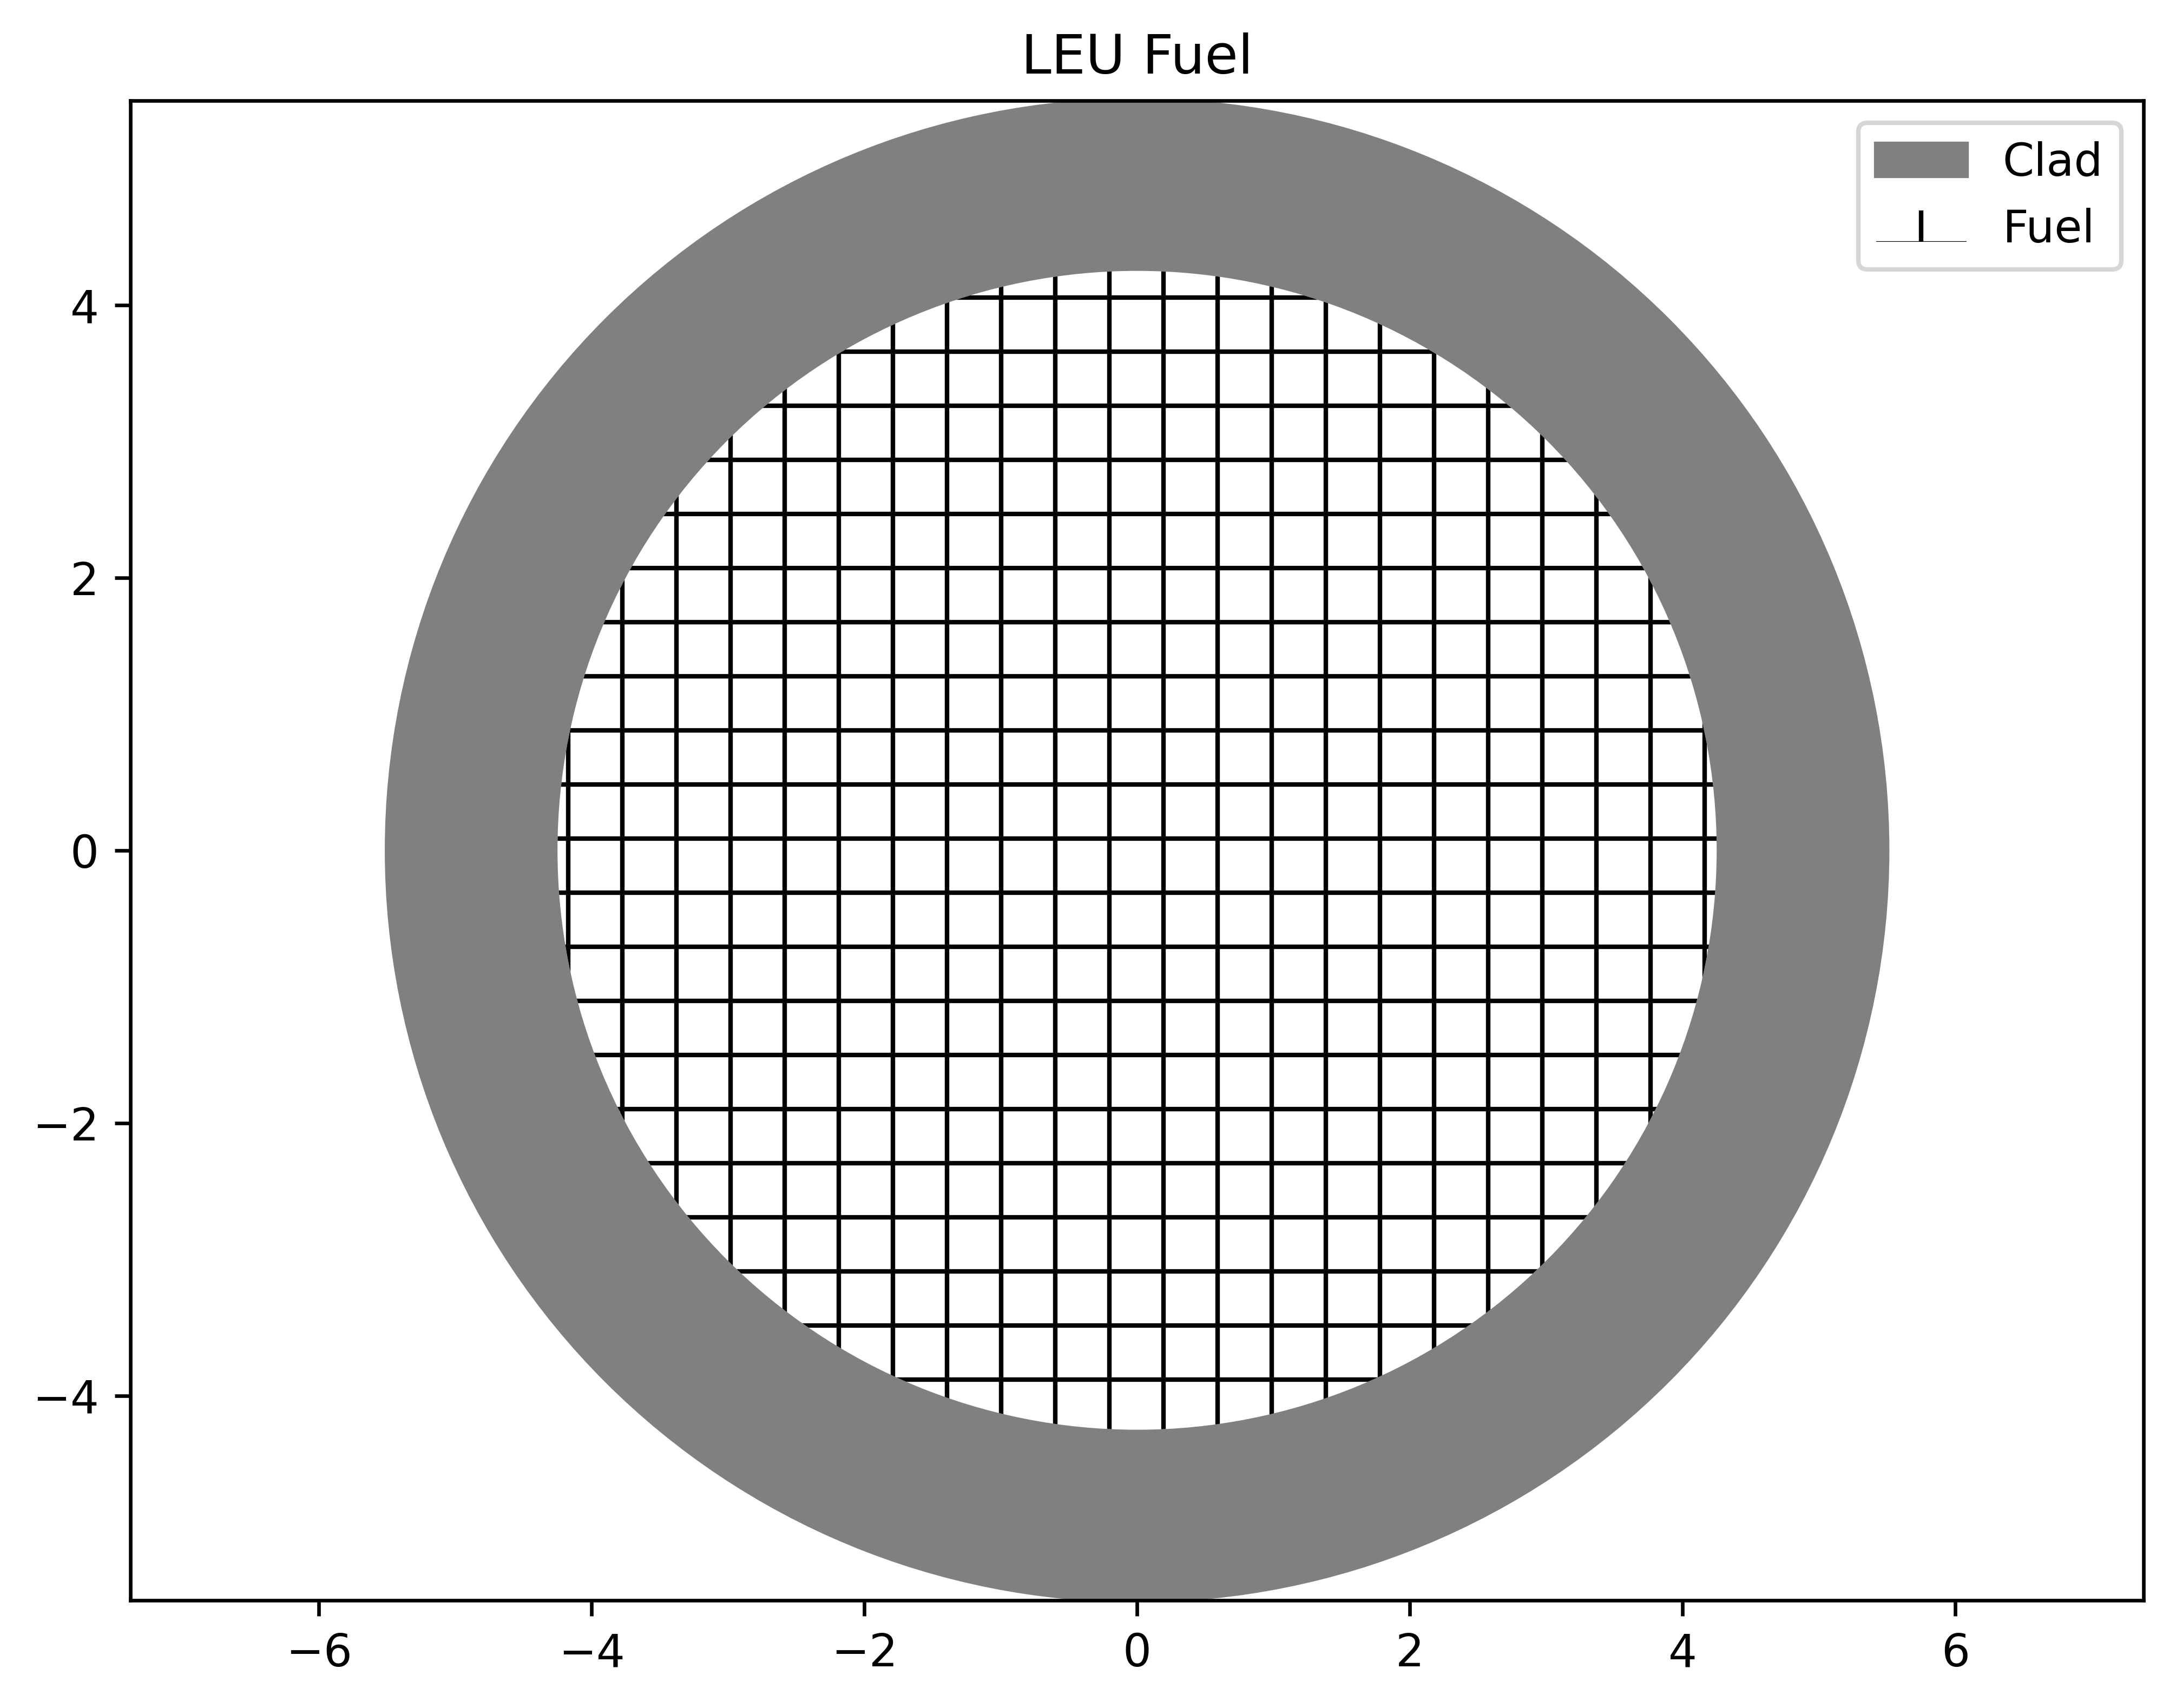

In [ ]:
fuel_radius = fuel_types["leu"]["fuel"]["thickness"]
clad_radius = fuel_radius + fuel_types["leu"]["clad"]["thickness"]

fig = plt.figure(figsize=(8,6), dpi=600)
fuel = plt.Circle((0,0),fuel_radius,
                  facecolor="white",label="Fuel", hatch="+")
clad = plt.Circle((0,0),clad_radius,color="gray",label="Clad")
plt.gca().add_patch(clad)
plt.gca().add_patch(fuel)
plt.title("LEU Fuel")
plt.axis("equal")
plt.legend()
plt.axis([-clad_radius,clad_radius,-clad_radius,clad_radius])
plt.show();

Given that we have a dictionary describing each type of fuel, we can define a lattice of fuel elements. We will make a 10 by 10 lattice of fuel with a 0.5 cm spacing between elements. Also, we will make every third element HEU and the rest LEU.


Each rod has a outer diameter of 11 cm
- HEU: radius = 5 + 0.5
- LEU: radius = 4.25 + 1.25

What should the distance between adjacent rod centers be?

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


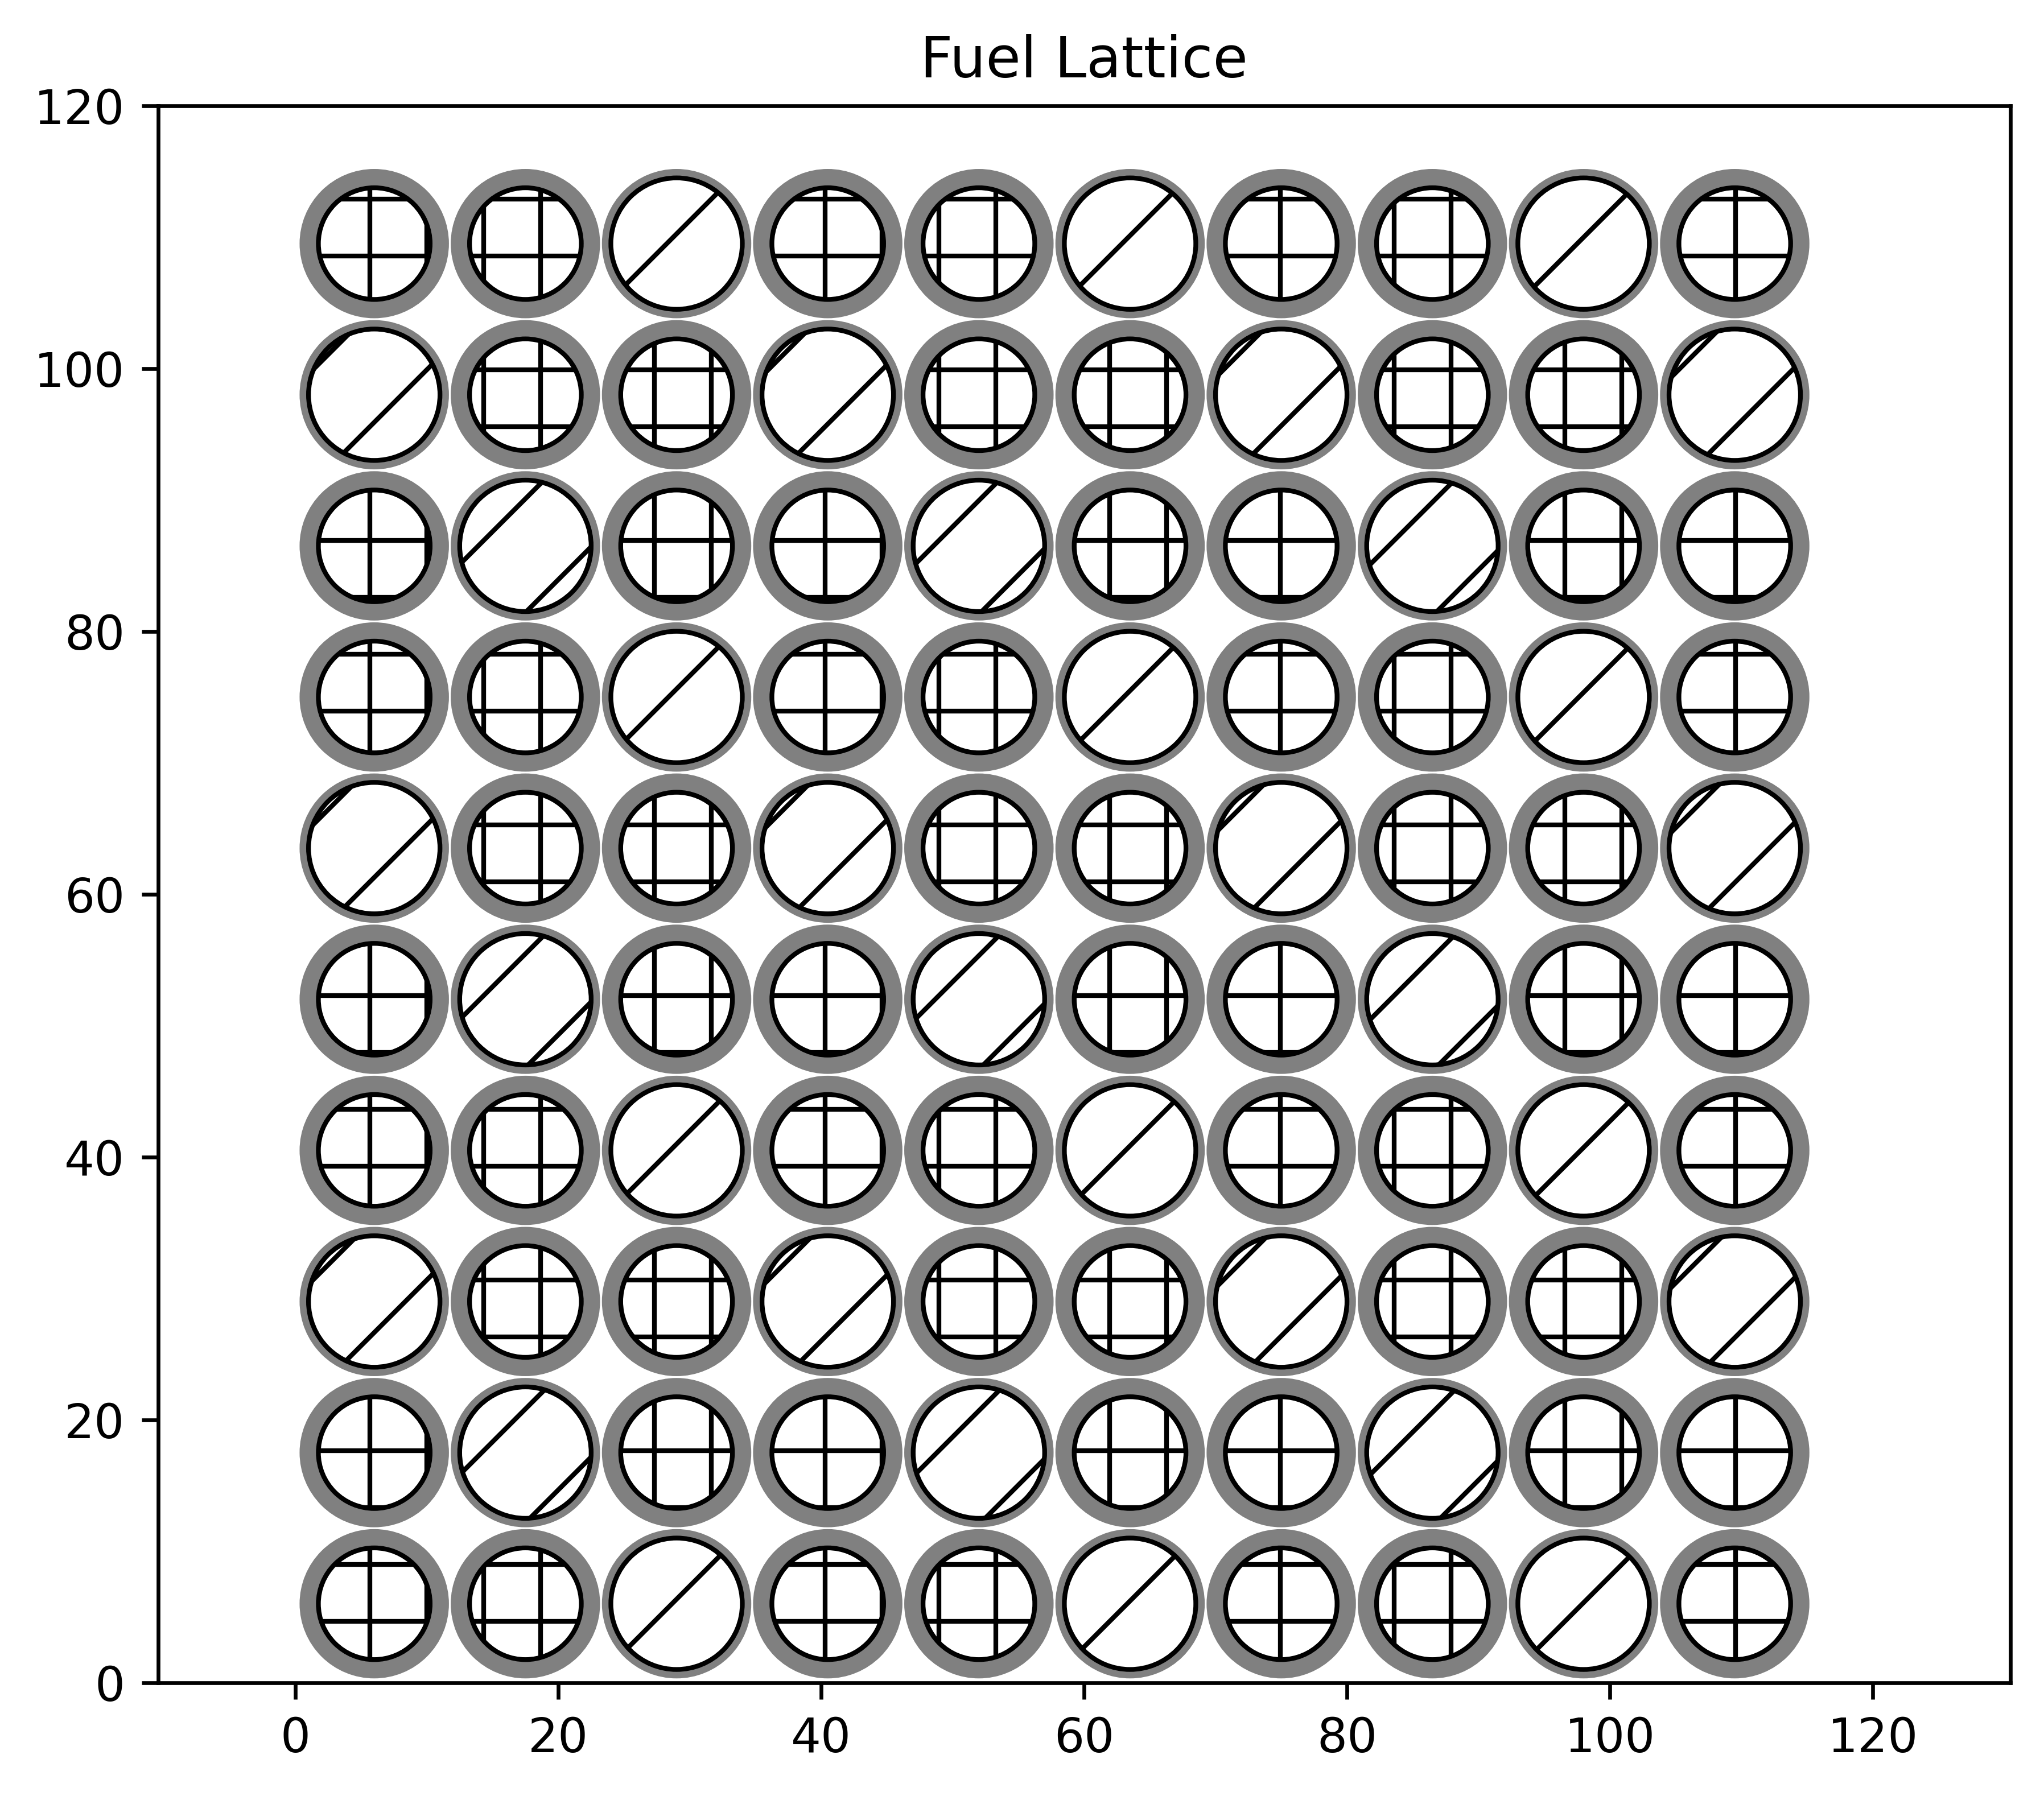

In [ ]:
import numpy as np

fuel_placements = {}
#10 x 10 lattice with 0.5 cm spacing
#every third pin is heu
x = np.arange(6.,120,12)
y = np.arange(6.,120,12)

fig = plt.figure(figsize=(7,6), dpi=600)
count = 1 #set up counting variable
for i in x:
    for j in y:
        if not(count % 3): #if count mod 3 is 0, then heu
            pin_type = "heu"
            hatch = "/"
        else: #else leu
            pin_type = "leu"
            hatch = "+"
        
        fuel_radius = fuel_types[pin_type]["fuel"]["thickness"]
        clad_radius = fuel_radius + fuel_types[pin_type]["clad"]["thickness"]
        fuel = plt.Circle((i,j),fuel_radius,facecolor="white",
                          edgecolor="black",hatch=hatch,
                          label="Fuel")
        clad = plt.Circle((i,j),clad_radius,color="gray",label="Clad")
        plt.gca().add_patch(clad)
        plt.gca().add_patch(fuel)
        count += 1 #increment count
plt.title("Fuel Lattice")
plt.axis("equal")
plt.axis([0,120,0,120])
plt.show();

With this lattice, if we knew the shape of the fundamental mode of the scalar flux, we
could compute the fission neutron production rate density at each point of the reactor. We
will assume a simple scalar flux shape and multiply the flux by the value of νΣf, that is the
product of the average number of fission neutrons produced, times the macroscopic fission
cross-section, to get the fission neutron production rate density. The following code computes
this quantity by evaluating νΣf at the middle of each fuel element.










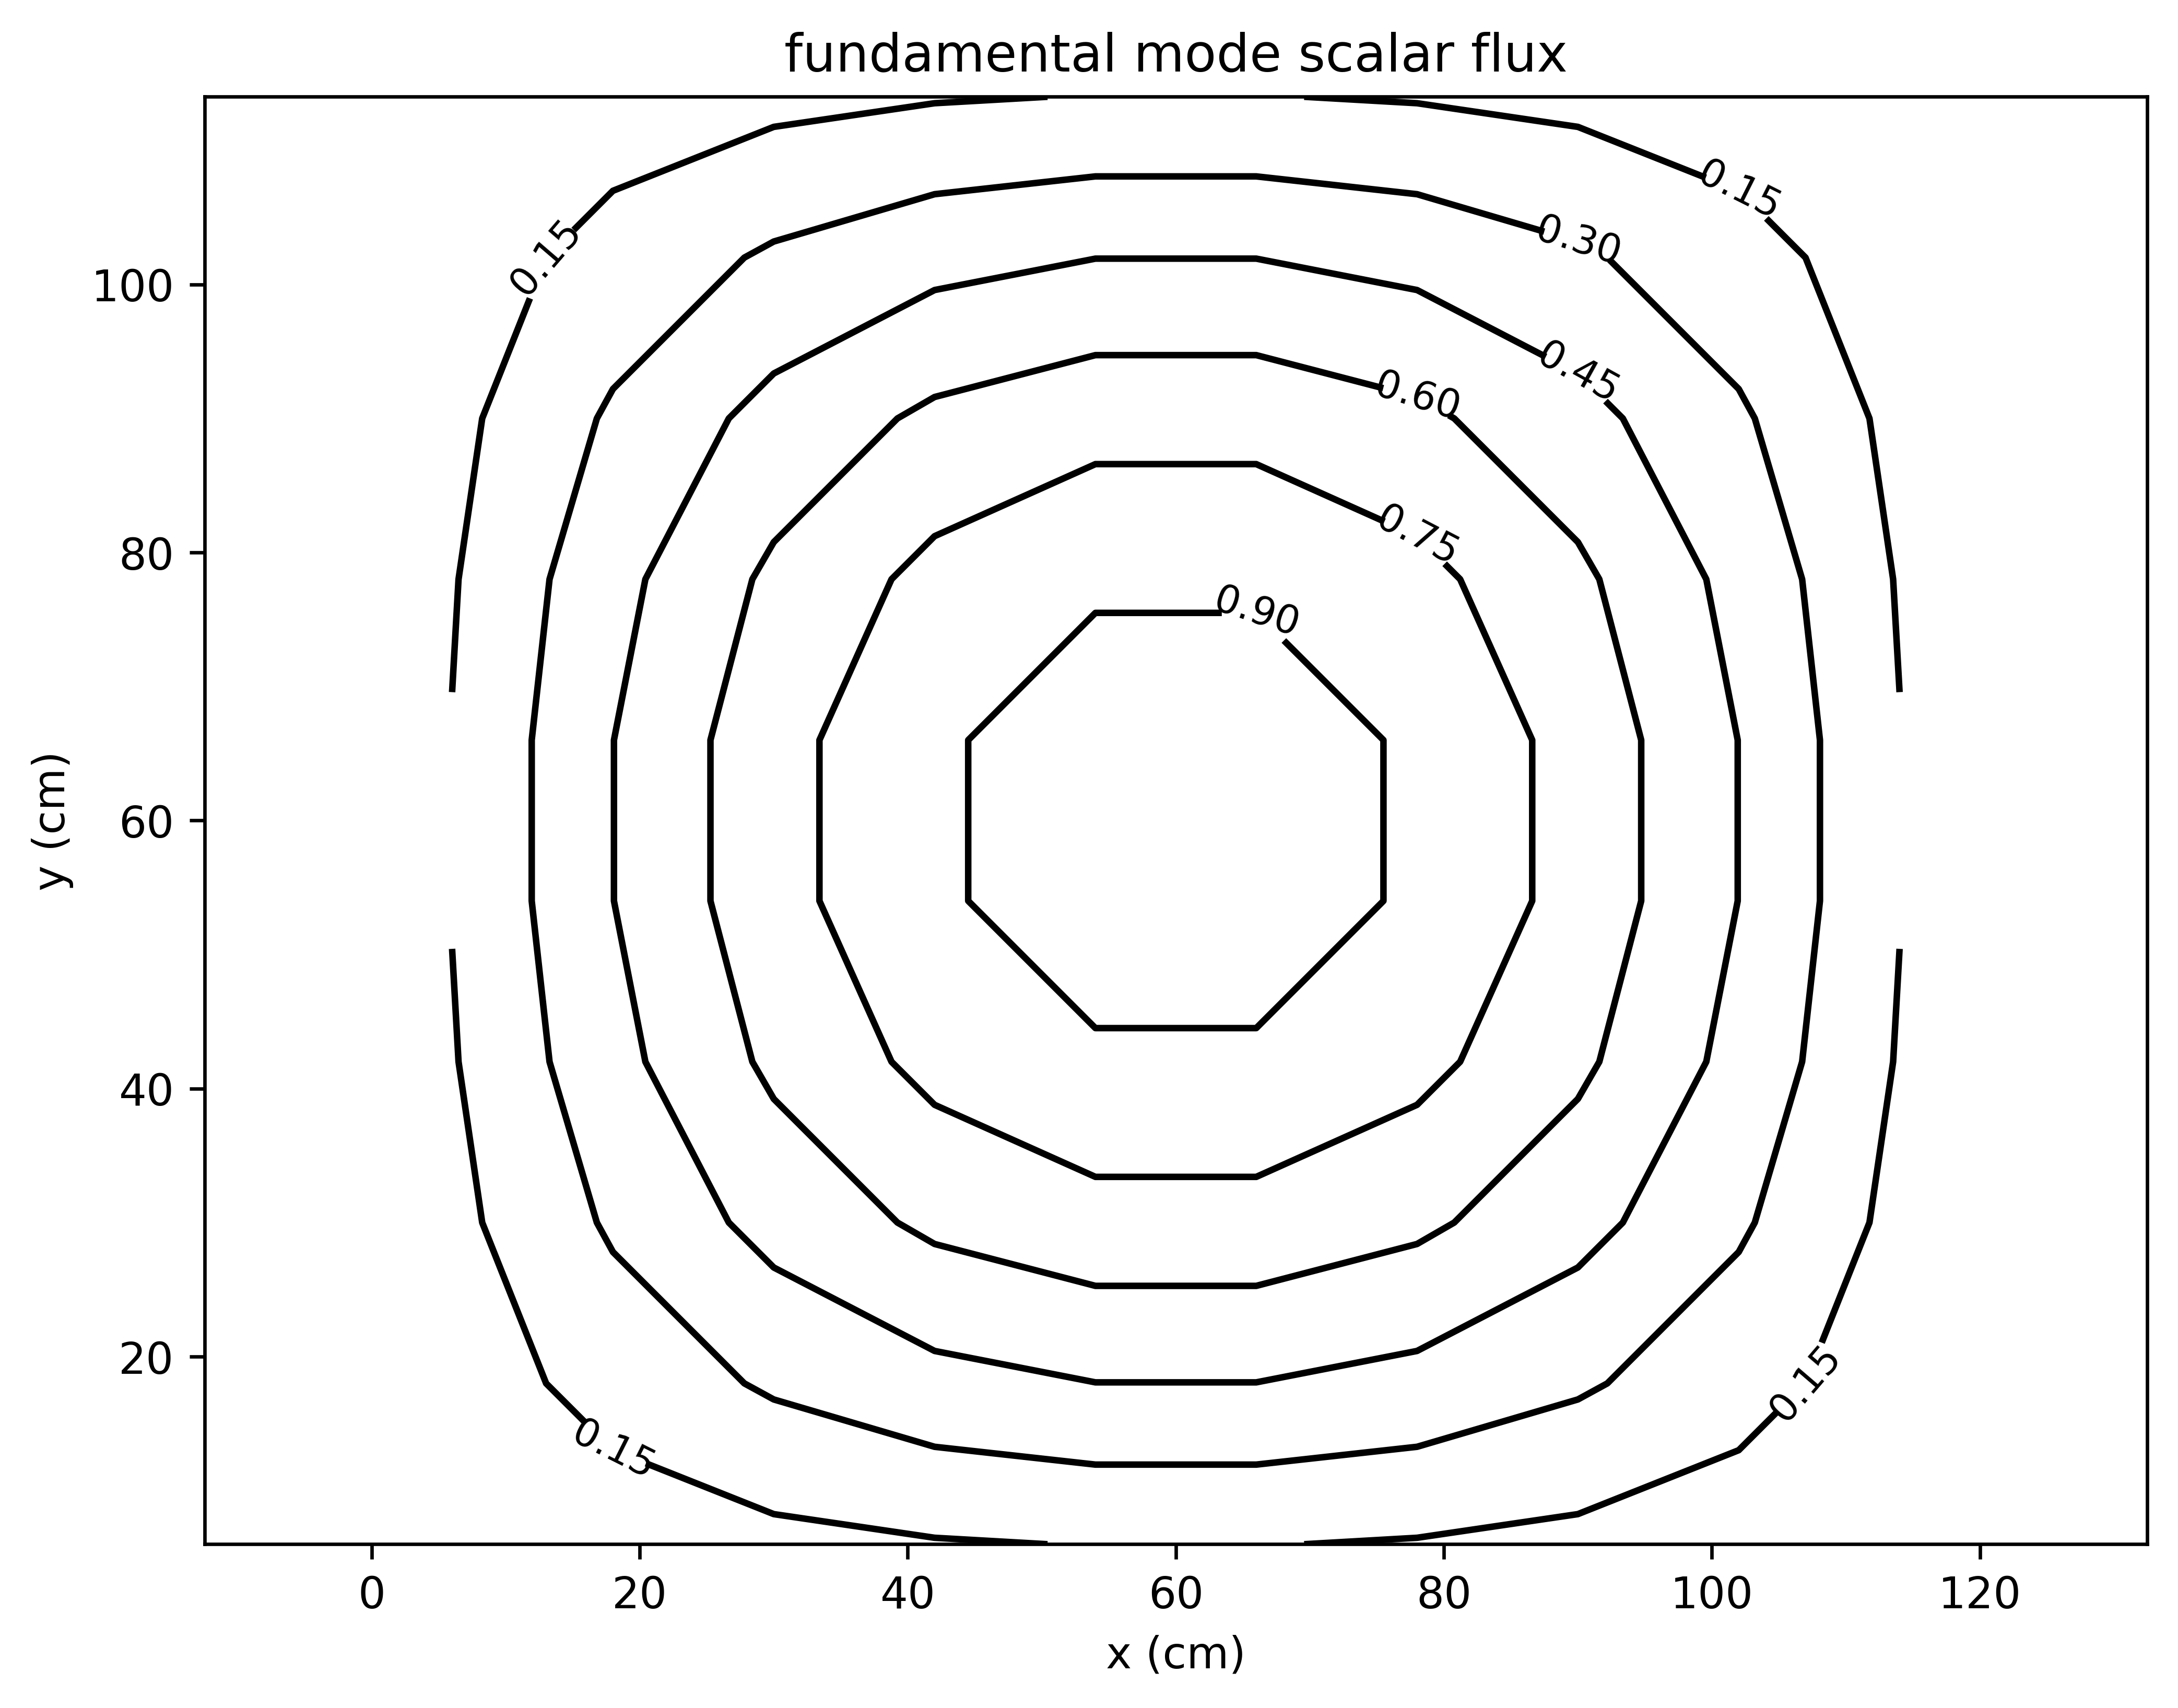

In [ ]:
fuel_placements = {}
#10 x 10 lattice with 0.5 cm spacing
#every third pin is heu
x = np.arange(6.,120,12)
y = np.arange(6.,120,12)
fig = plt.figure(figsize=(8,6), dpi=600)
X = np.zeros((x.size, x.size))
Y = X.copy()
Z = X.copy()
Zflux = Z.copy()
row = 0
col = 0
count = 1
for i in x:
    for j in y:
        if not(count % 3): #if count mod 3 is 0, then heu
            pin_type = "heu"
        else: #else leu
            pin_type = "leu"
        nusigf = fuel_types[pin_type]["fuel"]["nu sigma_f"]
        X[row,col] = i
        Y[row,col] = j
        Z[row,col]=nusigf*np.sin(i*np.pi/120)*np.sin(j*np.pi/120)
        Zflux[row,col]=np.sin(i*np.pi/120)*np.sin(j*np.pi/120)
        row += 1 #increment row
        count += 1 #increment count
    col += 1 #increment column
    row = 0
    
CS = plt.contour(X,Y,Zflux, colors="k")
plt.clabel(CS, fontsize=9, inline=1)
plt.xlabel("x (cm)")
plt.ylabel("y (cm)")
plt.axis("equal")
plt.title("fundamental mode scalar flux")
plt.show()






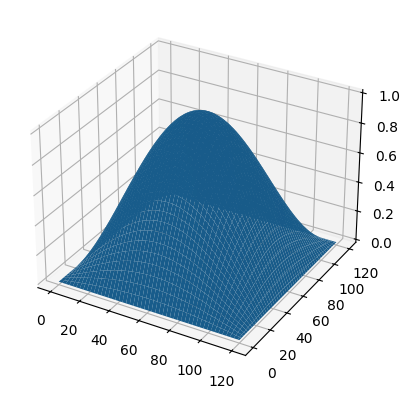

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 120, 100)
y = np.linspace(0, 120, 100)
X, Y = np.meshgrid(x, y)
Z = np.sin(X*np.pi/120) * np.sin(Y*np.pi/120)

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X, Y, Z)
plt.show()

Now plot the reaction rates 

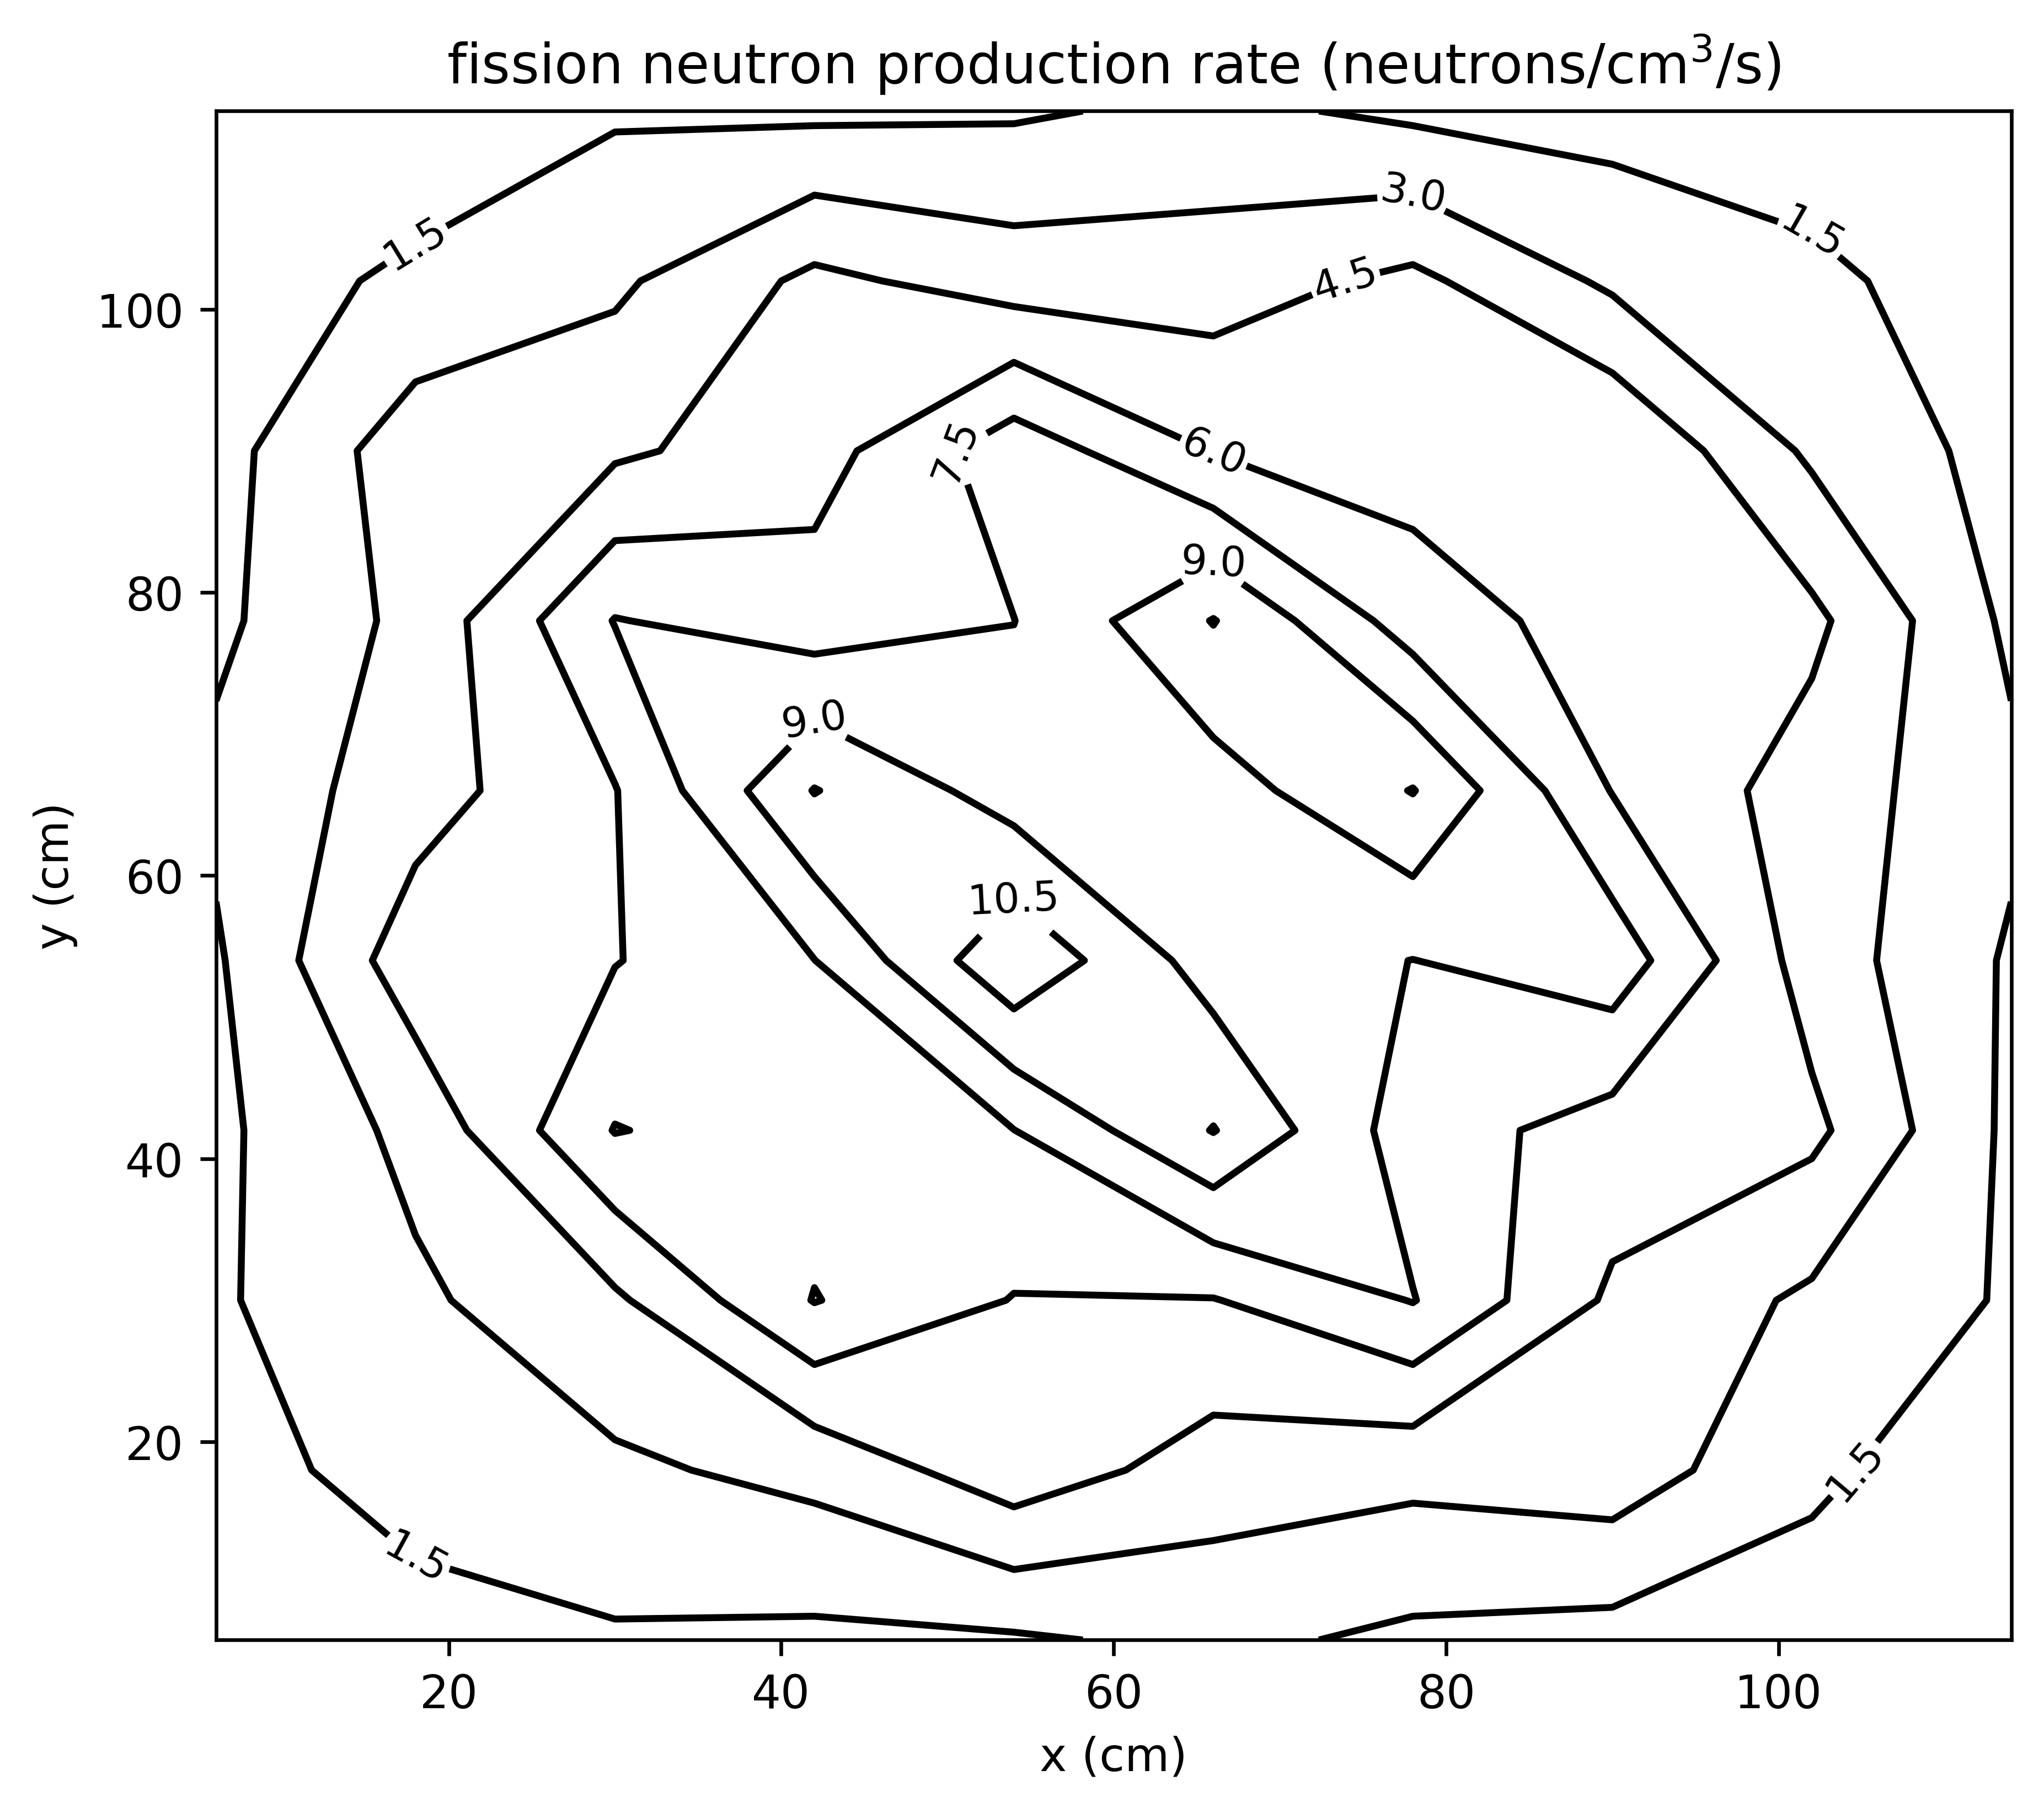

In [ ]:
fig = plt.figure(figsize=(7,6), dpi=600)
CS = plt.contour(X,Y,Z, colors="k")
plt.clabel(CS, fontsize=9, inline=1)
plt.xlabel("x (cm)");
plt.ylabel("y (cm)");
plt.title("fission neutron production rate (neutrons/cm$^3$/s)");
plt.show();

When we get to diffusion and Monte Carlo methods later this term, some of these techniques will be useful to us. 

## Functions passed to functions

In Python it is possible to pass the name of an existing function as a parameter to another
function. This name can then be used to execute the function and manipulate the results. This
ability to call a generic function results in very powerful codes as we will see.

In the example below, we are going to perform the integral of a function $f$ over the range between $a$ and $b$ using the midpoint, or rectangle rule of integration.  Break the domain $\left[a,b\right]$ into a finite number of intervals and evaluate the function at the midpoint of the interval.  Multiply the function evaluation by $\Delta x$, and sum over all the intervals to approximate the integral (area under the curve...).

In [37]:
def midpoint_rule(f,a,b,num_intervals):
    """integrate function f using the midpoint rule
    Args:
        f: function to be integrated, it must take 1 argument
        a: lower bound of integral range
        b: upper bound of integral range
        num_intervals: the number of intervals in [a,b]
    Returns:
        estimate of the integral
    """
    L = (b-a) #how big is the range
    dx = L/num_intervals #how big is each interval
    #midpoints are a+dx/2, a+3dx/2, ..., b-dx/2
    midpoints = np.arange(num_intervals)*dx+0.5*dx+a
    integral = 0
    for point in midpoints:
        integral = integral + f(point)
    return integral*dx

In [ ]:
# we'll pass the np.sin function in as the first argument...
import numpy as np
print(midpoint_rule(np.sin,0,np.pi,10))

2.0082484079079745


We can see how rapidly the error in this algorithm decreases as we make increase the number of intervals, decreasing the $\Delta x$...

First let's set up some of our variables for the problem... 

In [ ]:
import matplotlib.pyplot as plt
num_intervals = 8 #number of interval sizes
#run several different intervals
intervals = 10**np.arange(num_intervals)
error = np.zeros(num_intervals)
count = 0
a = 0
b = np.pi

print(intervals)
print(error)

[       1       10      100     1000    10000   100000  1000000 10000000]
[0. 0. 0. 0. 0. 0. 0. 0.]


Now let's go through each interval and get the value of the rule. 

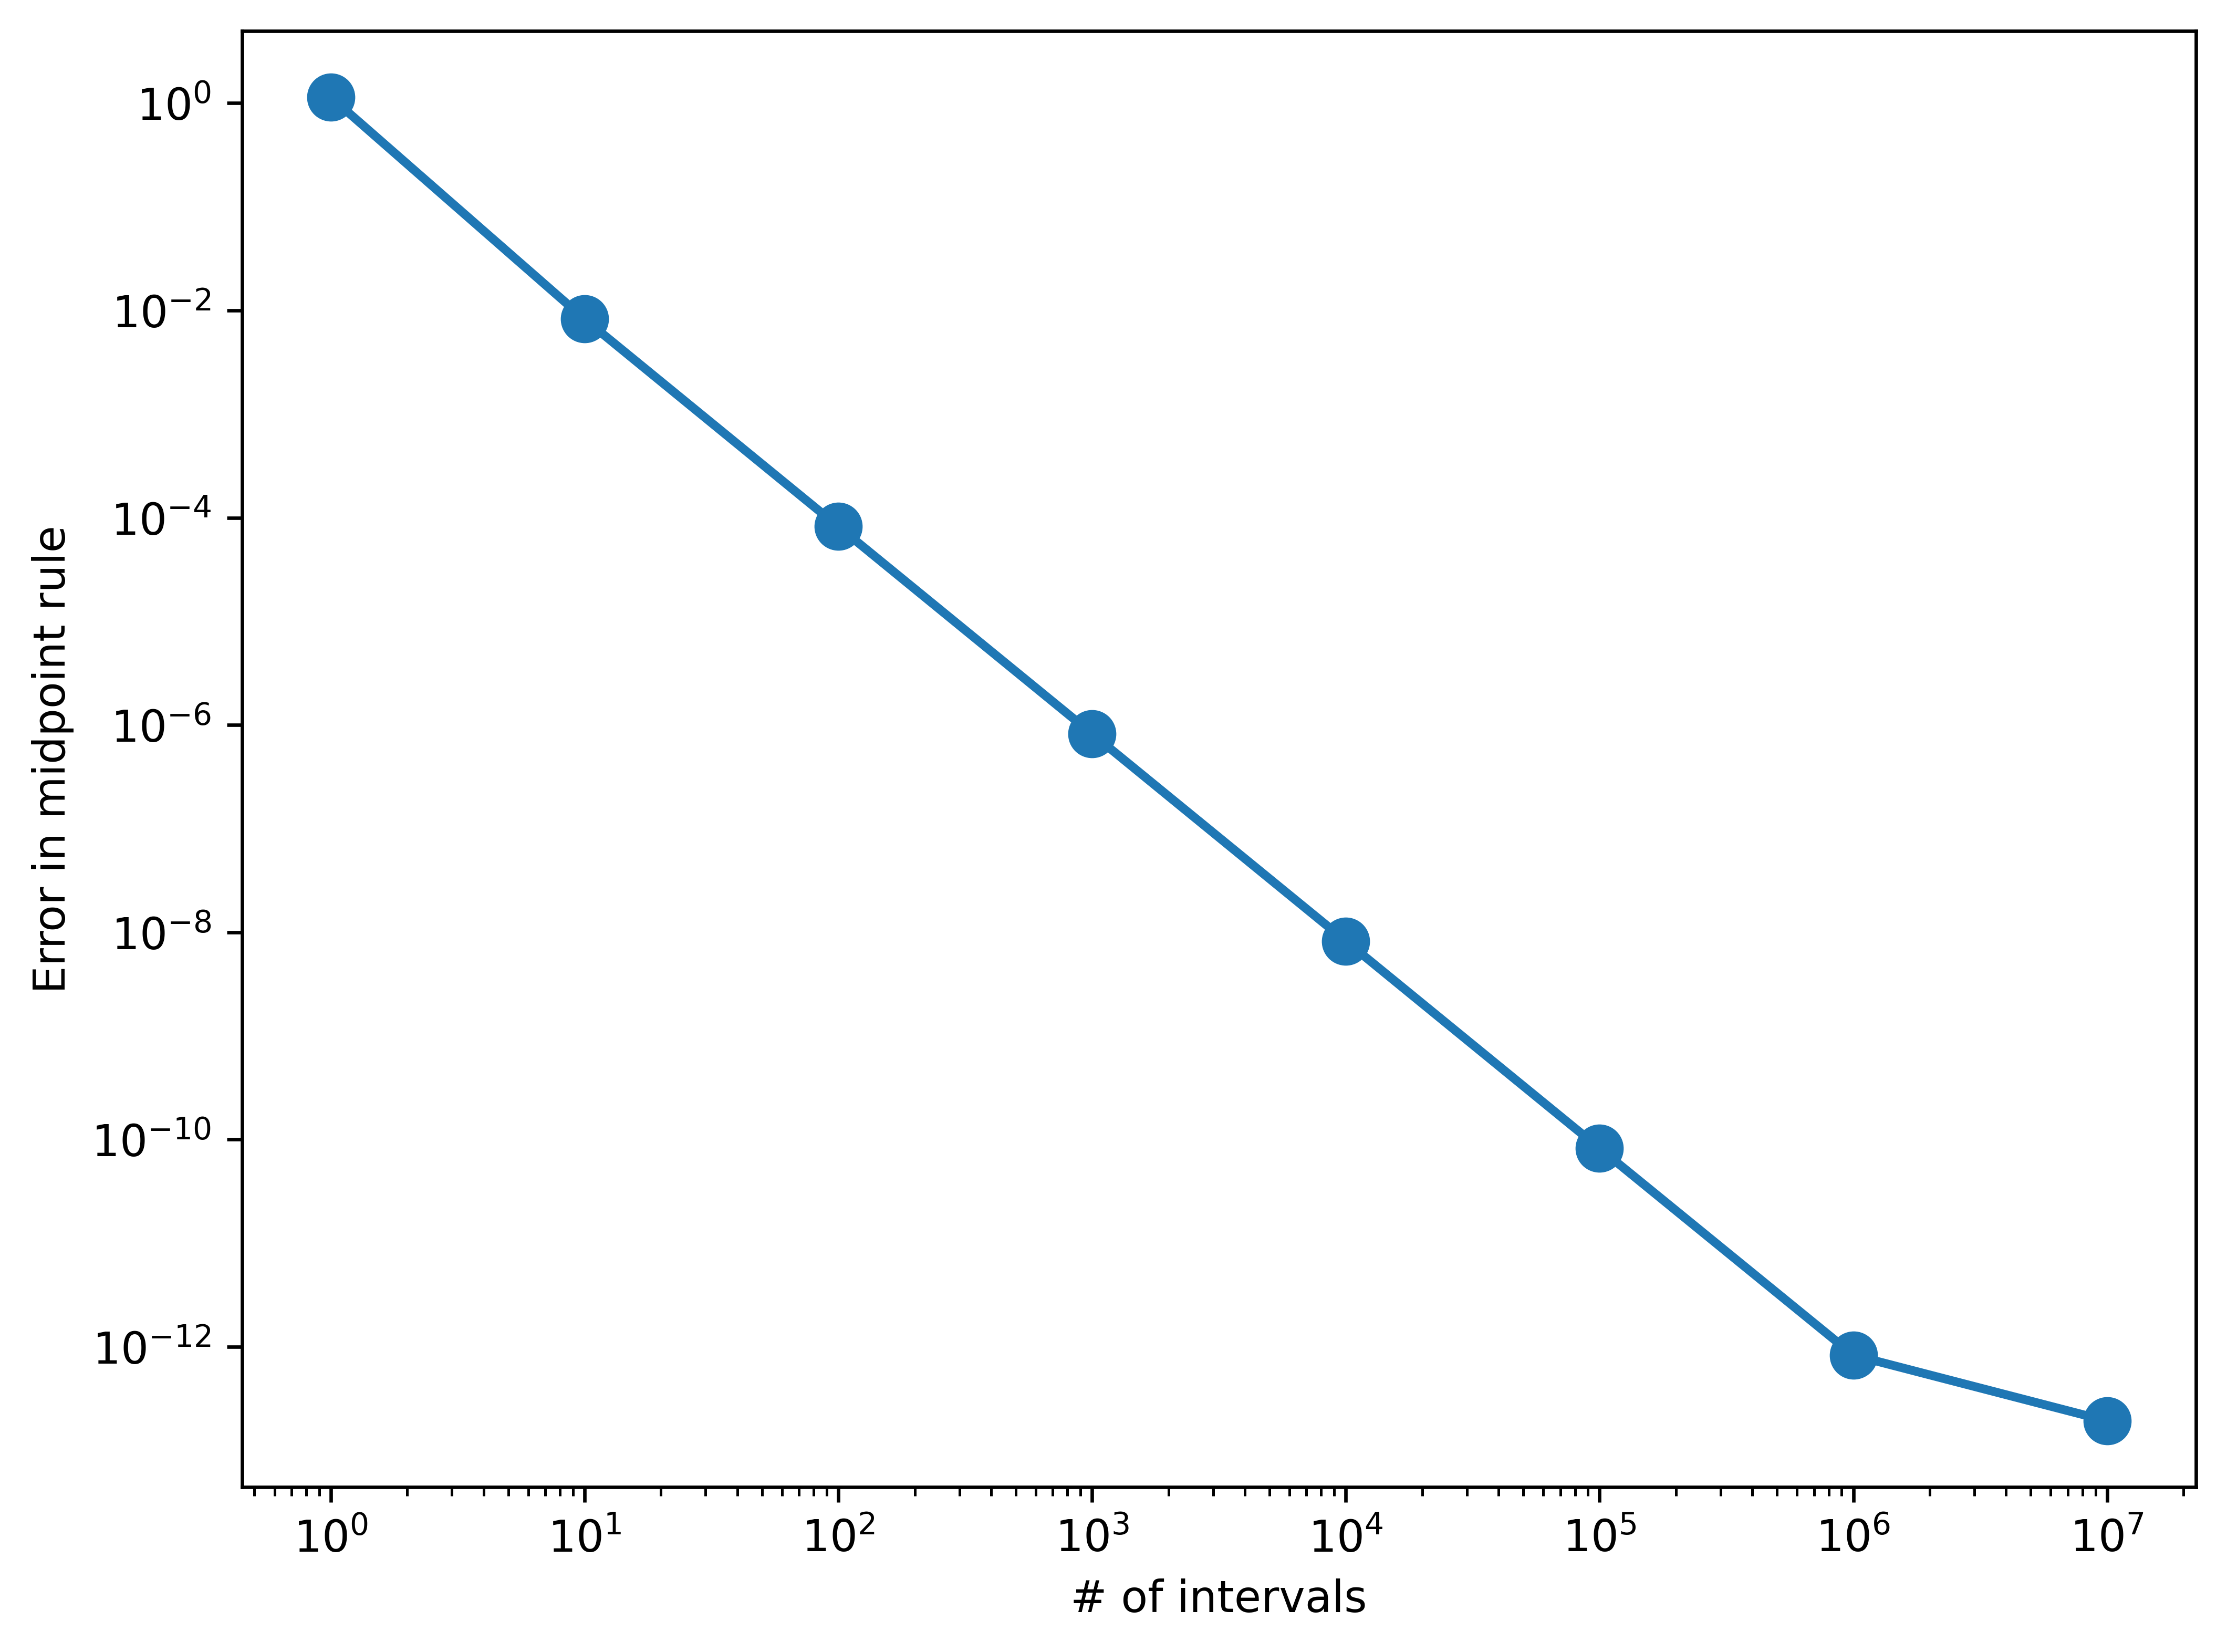

In [ ]:
for interval in intervals:
    error[count] = np.fabs(midpoint_rule(np.sin,a,b,interval)-2)
    count += 1
fig = plt.figure(figsize=(8,6), dpi=600)
plt.loglog(intervals,error,marker="o",
           markersize = 10,linewidth=2);
plt.xlabel("# of intervals")
plt.ylabel("Error in midpoint rule")
plt.show()

We can define our own functions and pass them to the midpoint rule function we defined.  For example, the Exponential Integral function:

$$ E_n (x) = \int\limits_1^{\infty} dt \frac{e^{-xt}}{t^n} $$

In [ ]:
def exp_int_argument(t,n=1,x=1):
    return np.exp(-x*t)/t**n
num_points = 10**6
upper_bound = 1000
print("Exact answer is 0.2193839343")
print("Our approximation with upper bound",upper_bound,
      "and",num_points,
      "points is",
      midpoint_rule(exp_int_argument,1,upper_bound,num_points))

Exact answer is 0.2193839343
Our approximation with upper bound 1000 and 1000000 points is 0.21938390380017958


We can employ Matplotlib to illustrate the midpoint rule for integration...

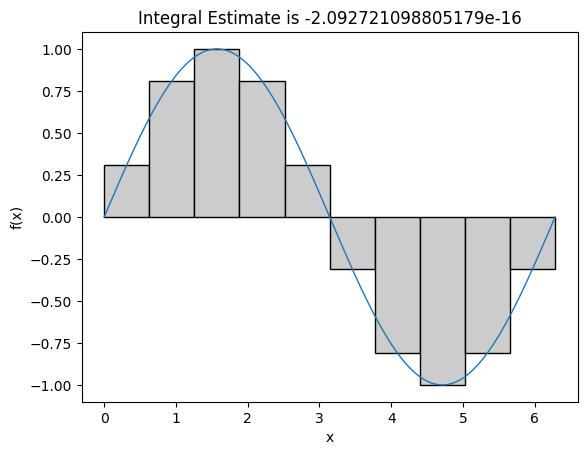

np.float64(-2.092721098805179e-16)

In [34]:
import numpy as np
import matplotlib.pyplot as plt


def midpoint_rule_graphical(f,a,b,num_intervals):
    """integrate function f using the midpoint rule
    Args:
        f: function to be integrated, it must take one argument
        a: lower bound of integral range
        b: upper bound of integral range
        num_intervals: the number of intervals to break [a,b] into
    Returns:
        estimate of the integral
    Side Effect:
        Plots intervals and areas of midpoint rule
    """
    fig = plt.figure()
    ax = plt.subplot(111)
    L = (b-a) #how big is the range
    dx = L/num_intervals #how big is each interval
    midpoints = np.arange(num_intervals)*dx+0.5*dx+a
    x = midpoints
    y = np.zeros(num_intervals)
    integral = 0
    count = 0
    for point in midpoints:
        y[count] = f(point)
        integral = integral + f(point)
        verts = [(point-dx/2,0)] + [(point-dx/2,f(point))]
        verts += [(point+dx/2,f(point))] + [(point+dx/2,0)]
        poly = plt.Polygon(verts, facecolor="0.8", edgecolor="k")
        ax.add_patch(poly)
        count += 1
    y = f(x)
    smooth_x = np.linspace(a,b,10000)
    smooth_y = f(smooth_x)
    plt.plot(smooth_x, smooth_y, linewidth=1)
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.title("Integral Estimate is " + str(integral*dx))
    plt.show()
    return integral*dx

midpoint_rule_graphical(np.sin,0,2*np.pi,10)

In [ ]:
import matplotlib.pyplot as plt

Answer is 0.2193839343


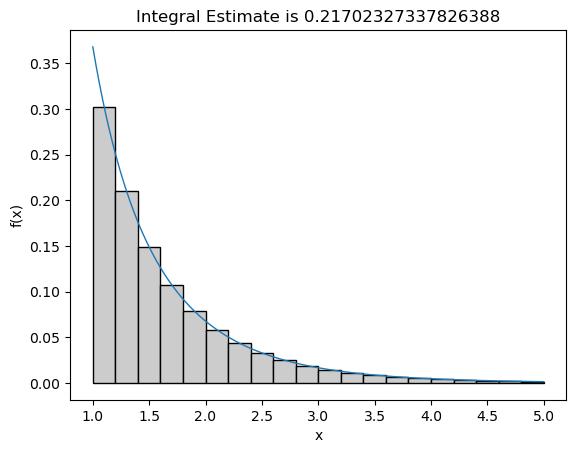

Our approximation with upper bound 5 and 20 points is 0.21702327337826388


In [ ]:
num_points = 20
upper_bound = 5
print("Answer is 0.2193839343")
print("Our approximation with upper bound",upper_bound,
      "and",num_points,"points is",
      midpoint_rule_graphical(exp_int_argument,1,upper_bound,num_points))

## Lambda functions

These are simple, one line functions. Important difference: lambda functions
give you access to all the variables available in the scope they are defined. This means
that lambda functions do not have their own variable scope.

By that I mean, `lambda x: f(x)` evaluates `f(x)` using whatever value of parameter x that is passed to it. 

If you define a lambda function inside another function, it has the same scope as the function it is defined in. 

The line at x = 0.0 is 1.0
The line at x = 5.0 is 11.0
The line at x = 4.0 is 9.0


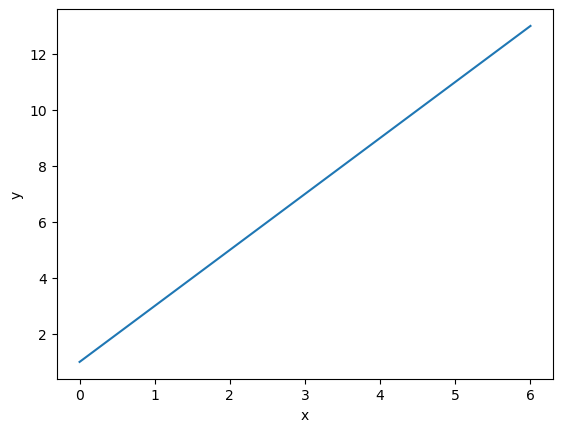

In [ ]:
simple_line = lambda x: 2.0*x + 1.0
print("The line at x = 0.0 is", simple_line(0))
print("The line at x = 5.0 is", simple_line(5))
print("The line at x = 4.0 is", simple_line(4))
x = np.linspace(0,6,50) ## Set linspace that makes sense
y = simple_line(x)
plt.plot(x,y)
plt.ylabel("y")
plt.xlabel("x")
plt.show()

Here we define the probability density function of a Gaussian as the integrand. A unit variance and zero
mean Gaussian is given by:

$$ f(x) = \frac{e^{-x^2}}{\sqrt{\pi}} $$

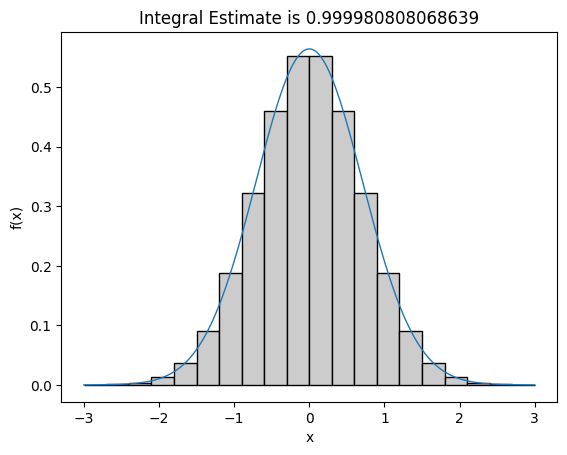

np.float64(0.999980808068639)

In [ ]:
#function to compute gaussian
gaussian = lambda x: np.exp(-x**2)/np.sqrt(np.pi)
midpoint_rule_graphical(gaussian,-3,3,20)

We can use the fact that lambda functions have the same scope as where they are defined to
make our midpoint rule integrate two-dimensional functions by defining two lambda func-
tions. 

We can trick our midpoint integration scheme into performing two dimensional integrals by observing that:

$$\int\limits_{a_y}^{b_y} dy \int\limits_{a_x}^{b_x} dx f(x,y) = \int\limits_{a_y}^{b_y} dy g(y), $$

where 

$$g(y) = \int\limits_{a_x}^{b_x} dx f(x,y). $$


- at any value of y, f(x,y) is a function of x alone
- the integral of f(x,y) along x (i.e., g(y)), is a function of y alone


We can use slightly modify our existing midpoint code and use a lambda function to compute an approximation to:

$$ \int\limits_{0}^{\pi} dy \int\limits_{0}^{\pi} dx \sin{(x)} \sin{(y)} = 4. $$

In [38]:
def midpoint_2D(f,ax,bx,ay,by,num_intervals_x,num_intervals_y):
    """integrate function f(x,y) using the midpoint rule
    Args:
        f: function to be integrated, it must take 2 arguments
        ax: lower bound of integral range in x
        bx: upper bound of integral range in x
        ay: lower bound of integral range in y
        by: upper bound of integral range in y
        num_intervals_x: the number of intervals in x
        num_intervals_y: the number of intervals in y
    Returns:
        estimate of the integral
    """
    g = lambda y: midpoint_rule(lambda x: f(x,y),ax,bx,num_intervals_x)
    return midpoint_rule(g,ay,by,num_intervals_y)

sin2 = lambda x,y:np.sin(x)*np.sin(y)
print("Estimate of the integral of sin(x)sin(y), over [0,pi] x [0,pi] is",
midpoint_2D(sin2,0,np.pi,0,np.pi,1000,1000))

Estimate of the integral of sin(x)sin(y), over [0,pi] x [0,pi] is 4.000003289869757


The lambda functions in this example tell Python to treat only a single variable as the
function parameter, and evaluate everything else based on the current scope:

$\texttt{lambda x: f(x,y)}$ evaluates $\texttt{f(x,y)}$ using whatever the current value of y is and the parameter x that the function was passed. 

The value of y is supplied by a parameter to the lambda function g.

The intricacies of defining lambda functions inside other lambda functions can get a bit
abstract, but remembering that they treat all variables in an expression that is not specified in
the parameter list as “known”, is the key to understanding how they function.